**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 11 - Optimización de funciones aplicado a la gestión**

---

# 📈 Optimización aplicada a objetivos organizacionales

Toda organización vive tomando decisiones del tipo **"¿cuánto?"**: cuánto producir, cuánto pedir,
cuánta gente asignar, cuánto stock mantener. En todas, la respuesta no es *"lo más posible"* ni
*"lo menos posible"*: **hay un punto óptimo**, y pasarse es tan malo como quedarse corto.

La derivada es la herramienta que encuentra ese punto. La receta es siempre la misma:

| Paso | Qué se hace |
|---|---|
| 1 | Escribir la función objetivo (lo que se quiere maximizar o minimizar) |
| 2 | Derivarla e igualar a cero → **candidatos** a óptimo |
| 3 | Verificar con la segunda derivada si es máximo o mínimo |
| 4 | **Interpretar**: ¿el número tiene sentido para la organización? |

> 🎯 El paso 4 es el que separa un ejercicio de matemática de una decisión de gestión.

En esta clase vamos a recorrer tres decisiones concretas: **minimizar un costo**, **encontrar el
tamaño de pedido óptimo** y **maximizar el beneficio de una línea de producción**.

---
# 📦 Caso 1: ¿de a cuánto conviene comprar? (lote óptimo)

**La situación.** Una distribuidora vende 12.000 unidades por año de un producto. Cada vez que hace
un pedido al proveedor paga \$ 45.000 de gastos fijos (flete, administración, recepción), sin
importar el tamaño del pedido. Y mantener una unidad en depósito durante un año cuesta \$ 900
(espacio, seguro, plata inmovilizada).

**La tensión es clarísima y aparece en cualquier depósito:**

| Si pedís… | Gasto de pedidos | Costo de mantener stock |
|---|---|---|
| **De a mucho**, pocas veces | ⬇️ bajo | ⬆️ alto (depósito lleno) |
| **De a poco**, muchas veces | ⬆️ alto | ⬇️ bajo |

Ninguno de los dos extremos conviene. **El óptimo está en el medio, y la derivada lo encuentra.**

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

D = 12_000      # demanda anual (unidades)
S = 45_000      # costo de hacer UN pedido
H = 900         # costo de mantener UNA unidad un año

q = sp.Symbol("q", positive=True)

# Costo total = costo de pedir + costo de mantener
costo_pedidos   = (D / q) * S        # cuántos pedidos por año × costo de cada uno
costo_stock     = (q / 2) * H        # stock promedio (la mitad del lote) × costo unitario
costo_total     = costo_pedidos + costo_stock

print("Función de costo total:", sp.simplify(costo_total))

# Optimizamos: derivada = 0
derivada = sp.diff(costo_total, q)
q_optimo = sp.solve(sp.Eq(derivada, 0), q)[0]

print("\nDerivada          :", sp.simplify(derivada))
print("Lote óptimo (q*)  :", float(q_optimo).__round__(1), "unidades")
print("Costo anual mínimo: $", f"{float(costo_total.subs(q, q_optimo)):,.0f}")

# Verificamos que sea un MÍNIMO (segunda derivada positiva)
print("\nSegunda derivada en q*:", float(sp.diff(costo_total, q, 2).subs(q, q_optimo)).__round__(4),
      "→ positiva, es un mínimo ✅")

In [ ]:
# El gráfico deja ver por qué el óptimo está donde está
q_vals = np.linspace(100, 3000, 400)
f_pedidos = (D / q_vals) * S
f_stock   = (q_vals / 2) * H
f_total   = f_pedidos + f_stock

plt.figure(figsize=(9, 5))
plt.plot(q_vals, f_pedidos, '--', label="Costo de hacer pedidos")
plt.plot(q_vals, f_stock,   '--', label="Costo de mantener stock")
plt.plot(q_vals, f_total,   linewidth=3, label="Costo TOTAL")
plt.axvline(float(q_optimo), color='black', linestyle=':',
            label=f"Lote óptimo = {float(q_optimo):.0f} u.")
plt.xlabel("Tamaño del pedido (unidades)")
plt.ylabel("Costo anual ($)")
plt.title("El óptimo está donde las dos fuerzas se equilibran")
plt.legend()
plt.grid(alpha=.3)
plt.show()

### 🧠 Lo que hay que ver en ese gráfico

Fijate **dónde cae el óptimo**: justo donde las dos curvas punteadas se cruzan. No es casualidad —
en el mínimo, el costo de pedir una vez más iguala exactamente al de mantener una unidad más.

Y mirá la forma de la curva total: **es bastante plana alrededor del mínimo**. Eso tiene una
consecuencia práctica enorme: si en vez de pedir 1.095 unidades pedís 1.000 (que es un número
redondo y entra justo en un pallet), el costo casi no cambia.

> 💼 **La lección de gestión:** el óptimo matemático es una **guía**, no una orden. Cuando la curva
> es plana, hay lugar para acomodarse a la logística real sin perder plata.

# Caso de A: Minimización de Costos en YPF 🛢️

Imaginemos a YPF, una empresa líder en energía, buscando optimizar sus operaciones para minimizar los costos de producción en una de sus plantas extractoras de petróleo.

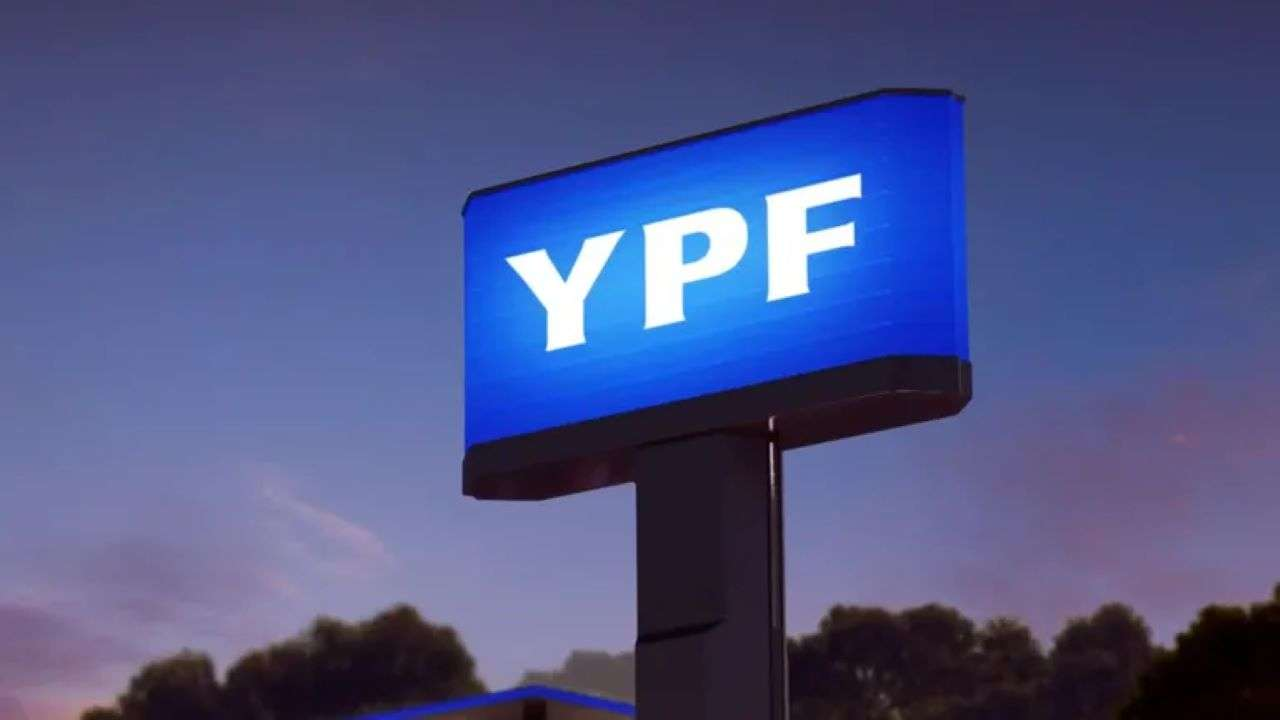

La estructura de costos totales de esta planta responde a la siguiente función:

$$C(q) = q^2 - 40q + 500$$

Donde:
*   $C(q)$ representa el costo total de producir $q$ unidades (por ejemplo, barriles de petróleo).
*   $q$ es la cantidad de petróleo producido.
*   El término $q^2 - 40q$ representa los costos variables, que dependen del nivel de producción. Estos costos pueden incluir la mano de obra, la energía consumida en la extracción y el procesamiento, y otros insumos que varían con la cantidad producida. La forma cuadrática ($q^2$) sugiere que puede haber rendimientos decrecientes o crecientes a escala en ciertos rangos de producción, o costos marginales que aumentan con la cantidad.
*   El término $500$ representa los costos fijos. Como mencionaste, estos 500 millones de dólares (o la unidad monetaria correspondiente) son costos que no varían con el nivel de producción en el corto plazo. En el contexto de una planta extractora de petróleo, estos altos costos fijos se deben a la **enorme inversión inicial** en infraestructura, maquinaria especializada (torres de perforación, equipos de bombeo, oleoductos), amortización de activos a largo plazo y el mantenimiento básico de las instalaciones, independientemente de cuánto petróleo se extraiga. Estos son ejemplos de "costos hundidos" o **altos costos de amortización y maquinaria** que son característicos de industrias de capital intensivo como la petrolera.


El objetivo de YPF, desde el punto de vista de la eficiencia operativa de esta planta, es encontrar el nivel de producción ($q$) que minimice este costo total. Esto es crucial para maximizar la rentabilidad general de la empresa.

In [9]:
q = sp.Symbol('q', real=True)

# Función de costo
C = q**2 - 40*q + 500

*   Condición de primer orden para un mínimo:

Para encontrar el mínimo de una función, se calcula su primera derivada con respecto a la variable de interés ($q$ en este caso) y se iguala a cero. La derivada de $C(q)$ con respecto a $q$ es:
$$\frac{dC}{dq} = 2q - 40$$
Igualando a cero:
$$2q - 40 = 0$$

*   condición de segundo orden para verificar que es un mínimo:
Para confirmar que el punto encontrado es un mínimo (y no un máximo o un punto de inflexión), se calcula la segunda derivada de la función de costo. Si la segunda derivada es positiva en el punto crítico, se trata de un mínimo.
$$\frac{d^2C}{dq^2} = \frac{d}{dq}(2q - 40) = 2$$



In [10]:
# Derivada primera (condición de mínimo)
C_deriv = sp.diff(C, q)

# Igualamos a cero
q_opt = sp.solve(C_deriv, q)[0]

# Evaluamos el costo mínimo
C_min = C.subs(q, q_opt)

# Derivada segunda para verificar que es mínimo
C_deriv2 = sp.diff(C_deriv, q)

# Resultados
print(f"Función C(q) =")
C


Función C(q) =


q**2 - 40*q + 500

In [11]:
print(f"Derivada: ")
C_deriv



Derivada: 


2*q - 40

In [12]:
print(f"Cantidad óptima q* = ")
q_opt


Cantidad óptima q* = 


20

In [13]:
print(f"Costo mínimo = ")
C_min


Costo mínimo = 


100

In [14]:
print(f"Segunda derivada, debe ser > 0 para mínimo:")
C_deriv2


Segunda derivada, debe ser > 0 para mínimo:


2

*   Resultados:
El código imprime la función de costo, su primera derivada, la cantidad óptima que minimiza el costo, el valor del costo mínimo y la segunda derivada para verificar.

🎯 ¿Por qué no hacemos la segunda derivada en los ejercicios de maximización de monopolio?

1. ✅ Porque la función es concava por construcción
En la mayoría de los casos introductorios, la función de beneficio de un monopolio tiene esta forma:

$$π(q)= Ingreso \ total - Costo \ total$$
Si la demanda es lineal decreciente y el costo es lineal o cuadrático, el ingreso total es una parábola invertida, y el beneficio termina siendo una función cóncava como:

$$π(q)= -aq^2 +bq+c$$
Entonces ya sabemos que tiene un único máximo.

2. 📉 El gráfico y el contexto económico ya garantizan que hay un máximo
La curva de ingreso marginal es decreciente.

El costo marginal puede ser constante o creciente.

---
Minimize la siguiente funcion

$$C(q) = 8q^2 - 4q^2 + q + 3q - q + 800$$

In [ ]:
#Defina la ecuacion

In [ ]:
#haga las derivadas

In [ ]:
#print



---



# Ejercicios de Práctica 📝
Los ejercicios van de menor a mayor dificultad, pueden ayudarse en 2 con IA el objetivo es que traten de cranear lo maximo posible, copiar e interpretar lo que escriban, letsgoo  :D



## Ejercicio 3: Minimización de Costos Lineal

Una empresa tiene una función de costo total lineal:

$$C(q) = 5q + 100$$

**Objetivo:**

1.  Encontrar la cantidad ($q^*$) que minimiza el costo total.
2.  Calcular el costo mínimo.

*(Nota: Piensa en la forma de esta función y si tiene un mínimo en un rango de producción positivo. Este ejercicio es un poco conceptual).*

# Bibliografia y Recomendaciones 📚



*   Libros =

    1.   Pindyck, Robert & Rubinfeld, Daniel (2017). Microeconomics. Pearson.
    2.   Varian, Hal (2010). Intermediate Microeconomics: A Modern Approach. W.

*   Videos=
    1.   https://www.youtube.com/watch?v=npoNbXXS4oQ&pp=ygUWZWNvbm9taWEgZXhwbGljYWRvIGVuIA%3D%3D --> Economia
    2.   https://www.youtube.com/watch?v=nKPbfIU442g&t=26156s&pp=ygUMZGFsdG8gcHl0aG9u --> curso gratuito de python en yt


*   Peliculas=
    1.   Big short (Peliculon)

*   Podcast=
    1.   La fabrica podcast --> Industrias de arg
    2.   FMI Podcast (el zar de las finanzas) --> eco Argentina

*   Juego=
    1.   Brillant --> para practicar codigo, logica programacional, etc.



---
# 💵 Caso 3: ¿a qué precio conviene vender?

**La situación.** Una empresa de servicios cobra hoy \$ 40.000 por mes y tiene 800 clientes. El área
comercial hizo una prueba y estimó que **por cada \$ 1.000 que sube el precio, pierde 15 clientes**.
Atender a cada cliente cuesta \$ 12.000 por mes, y la estructura fija cuesta \$ 6.000.000.

La pregunta del directorio es la de siempre: **¿conviene aumentar el precio?**

La respuesta no es obvia, porque hay dos efectos que van en direcciones opuestas:

| Si sube el precio | Efecto |
|---|---|
| Cada cliente deja **más** plata | ⬆️ a favor |
| Se van **algunos** clientes | ⬇️ en contra |

**Cuál de los dos gana depende de dónde estemos parados.** Vamos a encontrar el punto exacto.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

p = sp.Symbol("p", positive=True)      # precio mensual

# Cuántos clientes quedan a cada precio (parte de 800 a $40.000)
clientes = 800 - 15 * (p - 40_000) / 1_000

COSTO_POR_CLIENTE = 12_000
COSTO_FIJO        = 6_000_000

ingreso   = p * clientes
costo     = COSTO_FIJO + COSTO_POR_CLIENTE * clientes
beneficio = sp.expand(ingreso - costo)

print("Clientes según el precio :", sp.simplify(clientes))
print("Beneficio                :", beneficio)

# Optimizamos
p_optimo = sp.solve(sp.Eq(sp.diff(beneficio, p), 0), p)[0]
print(f"\nPrecio óptimo      : $ {float(p_optimo):,.0f}")
print(f"Clientes con ese precio: {float(clientes.subs(p, p_optimo)):,.0f}")
print(f"Beneficio mensual  : $ {float(beneficio.subs(p, p_optimo)):,.0f}")

# ¿Es máximo?
print(f"\nSegunda derivada: {float(sp.diff(beneficio, p, 2)):.4f} → negativa, es un máximo ✅")

In [ ]:
# Comparamos contra la situación actual
beneficio_hoy = float(beneficio.subs(p, 40_000))
beneficio_opt = float(beneficio.subs(p, p_optimo))

print(f"Hoy    ($40.000, 800 clientes) : $ {beneficio_hoy:,.0f}")
print(f"Óptimo (${float(p_optimo):,.0f}, {float(clientes.subs(p, p_optimo)):.0f} clientes) : $ {beneficio_opt:,.0f}")
print(f"\nMejora: $ {beneficio_opt - beneficio_hoy:,.0f} por mes")
print(f"        $ {(beneficio_opt - beneficio_hoy) * 12:,.0f} por año")

# El gráfico
p_vals = np.linspace(20_000, 80_000, 400)
b_vals = [float(beneficio.subs(p, v)) for v in p_vals]

plt.figure(figsize=(9, 5))
plt.plot(p_vals, b_vals, linewidth=3)
plt.axvline(float(p_optimo), color='black', linestyle=':', label=f"Óptimo: $ {float(p_optimo):,.0f}")
plt.axvline(40_000, color='gray', linestyle='--', label="Precio actual: $ 40.000")
plt.xlabel("Precio mensual ($)")
plt.ylabel("Beneficio mensual ($)")
plt.title("¿A qué precio conviene vender?")
plt.legend()
plt.grid(alpha=.3)
plt.show()

### 🧠 Lo que dice el resultado

Fijate que el óptimo **no es el precio más alto posible**, ni el que retiene más clientes. Está en el
medio, y la derivada lo encontró en dos líneas.

Pero acá viene la parte importante, la que separa el ejercicio de la decisión real:

> ⚠️ **Todo este resultado se apoya en un solo dato: "por cada \$1.000 se pierden 15 clientes".**
> Si ese número está mal estimado, el óptimo se mueve. El modelo es tan bueno como el dato que le
> diste.

Por eso, en la práctica, la respuesta al directorio nunca es *"el precio óptimo es \$X"*. Es:
*"con la sensibilidad que medimos, el óptimo está en \$X; si la sensibilidad fuera el doble, el
óptimo bajaría a \$Y"*. **Dar el rango es más honesto y más útil que dar el número solo.**

In [ ]:
# ¿Y si la sensibilidad fuera distinta? Probamos varios escenarios
print("Si por cada $1.000 de aumento se pierden...")
for sensibilidad in [5, 10, 15, 20, 30]:
    cl = 800 - sensibilidad * (p - 40_000) / 1_000
    ben = sp.expand(p * cl - (COSTO_FIJO + COSTO_POR_CLIENTE * cl))
    p_opt = sp.solve(sp.Eq(sp.diff(ben, p), 0), p)[0]
    print(f"   {sensibilidad:>2} clientes → precio óptimo $ {float(p_opt):>9,.0f}  "
          f"(beneficio $ {float(ben.subs(p, p_opt)):>11,.0f})")

print("\nCuanto MÁS sensibles son los clientes, MÁS bajo conviene poner el precio.")

---
# 📝 Ejercicios de práctica

> 💡 En todos: planteá la función, derivá, igualá a cero, **verificá con la segunda derivada** y
> —sobre todo— **interpretá el resultado**. Un número sin interpretación no resuelve nada.

### ✅ Ejercicio 1 — Lote óptimo con otros datos

Un supermercado vende 36.000 unidades por año de un producto. Hacer un pedido cuesta \$ 25.000 y
mantener una unidad en góndola y depósito cuesta \$ 600 al año.

1. Encontrá el **lote óptimo** de pedido.
2. ¿Cuántos pedidos por año implica eso?
3. ¿Cuál es el costo anual total en el óptimo?
4. El proveedor ofrece un descuento si le comprás de a 5.000 unidades. Sin hacer la cuenta del
   descuento: ¿cuánto **más** te costaría en logística pedir de a 5.000? ¿Y con eso, qué le
   contestarías al proveedor?

In [ ]:
# Tu código acá

### ✅ Ejercicio 2 — El tamaño del equipo

Un centro de atención recibe 20.000 consultas por mes. Cada empleado resuelve 900 consultas
mensuales y cuesta \$ 1.400.000 por mes. Cada consulta **sin resolver** genera un costo estimado de
\$ 8.000 (reclamos, pérdida de cliente, retrabajo).

1. Escribí el costo total mensual en función de la cantidad de empleados $n$.
2. Encontrá la cantidad de empleados que **minimiza** el costo total.
3. ¿Conviene contratar hasta resolver el 100% de las consultas? Justificá con los números.
4. ¿Qué pasaría si el costo de una consulta sin resolver fuera de \$ 30.000 en vez de \$ 8.000?

In [ ]:
# Tu código acá

### ✅ Ejercicio 3 — Minimización de costos de producción

Una planta tiene la función de costo medio:

$$CMe(q) = \frac{4.000.000}{q} + 3.500 + 2q$$

1. ¿Qué representa cada uno de los tres términos?
2. Encontrá la cantidad que **minimiza el costo medio** (la escala más eficiente de la planta).
3. Calculá el costo medio mínimo.
4. Verificá una propiedad conocida: en el mínimo del costo medio, **el costo marginal lo cruza**.
   Calculá el costo marginal en ese punto y compará.

In [ ]:
# Tu código acá

### ✅ Ejercicio 4 — Integrador: "Logística del Norte"

Una distribuidora te contrata para revisar dos decisiones a la vez:

**Datos:**

| Concepto | Valor |
|---|---|
| Demanda anual | 24.000 unidades |
| Costo de hacer un pedido | \$ 60.000 |
| Costo de mantener una unidad por año | \$ 1.200 |
| Precio de venta actual | \$ 15.000 |
| Clientes actuales | 24.000 unidades/año |
| Sensibilidad al precio | por cada \$ 500 de aumento, se pierden 400 unidades de demanda |
| Costo variable por unidad | \$ 9.000 |

**Se pide:**

1. Calculá el **lote óptimo de pedido** con la demanda actual.
2. Calculá el **precio que maximiza el beneficio**.
3. **Acá está el punto:** si cambia el precio, cambia la demanda… y si cambia la demanda, cambia el
   lote óptimo. Recalculá el lote óptimo con la demanda que corresponde al precio óptimo.
4. ¿Cuánto mejoró el beneficio anual total respecto de la situación actual?
5. **La pregunta de gestión:** ¿qué decisión tomarías primero, la de precio o la de logística?
   ¿Por qué?

In [ ]:
# Tu código acá